In [2]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

setting configaration

In [4]:
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x :f"{x:.3f}")
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'axes.titlesize':10,
    'axes.labelsize':9,
    'xtick.labelsize':8,
    'ytick.labelsize':8
})
RANDOM_STATE=42
CSV_FILE="insurance.csv"
target_cols="=charges"


In [5]:
df=pd.read_csv(CSV_FILE)

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [8]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [9]:
for col in df.columns:
    print(df[col].value_counts().head())

age
18    69
19    68
46    29
52    29
50    29
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
30.800     8
31.350     8
30.495     8
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
6203.902     1
12981.346    1
28101.333    1
28923.137    1
Name: count, dtype: int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
nums_cols=df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(include=["string"]).columns.tolist()

In [12]:
cat_cols

[]

In [13]:
duplicate_mask=df.duplicated()
duplicate_mask.sum()
df=df.drop_duplicates()

In [14]:
df[nums_cols].describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428


In [15]:
 for col in cat_cols:
    print(df[col].value_counts())

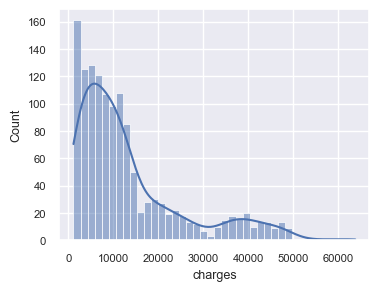

In [16]:
plt.figure(figsize=(4,3))
sns.histplot(df['charges'],bins=40,kde=True)
plt.show()

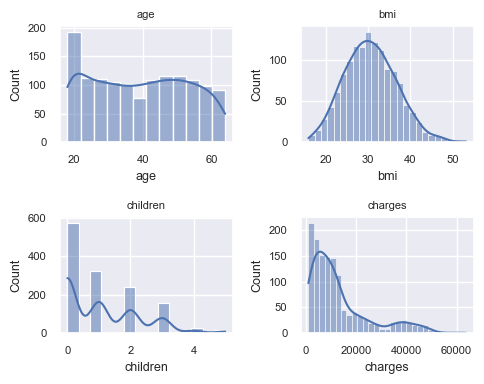

In [17]:
fig,axes=plt.subplots(2,2,figsize=(5,4))
axes=axes.flatten()

for i,col in enumerate(nums_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()

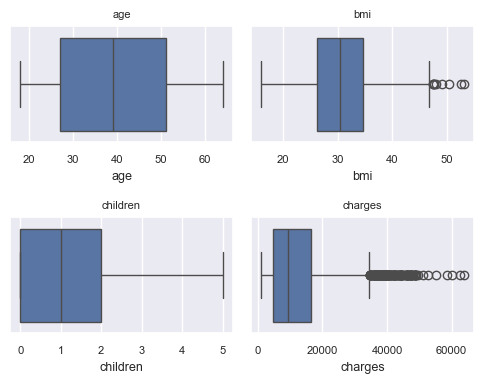

In [18]:
fig,axes=plt.subplots(2,2,figsize=(5,4))
axes=axes.flatten()

for i,col in enumerate(nums_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)
plt.tight_layout()
plt.show()

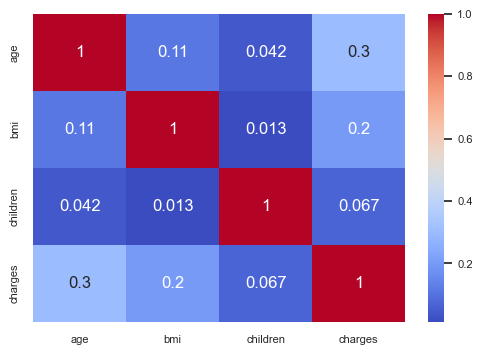

In [19]:


plt.figure(figsize=(6,4))
sns.heatmap(df[nums_cols].corr(),annot=True,cmap="coolwarm")
    # axes[i].set_title(col,fontsize=8)
# plt.tight_layout()
plt.show()

In [20]:
corr_target=df[nums_cols].corr()['charges'].sort_values(ascending=True)
corr_target

children   0.067
bmi        0.198
age        0.298
charges    1.000
Name: charges, dtype: float64

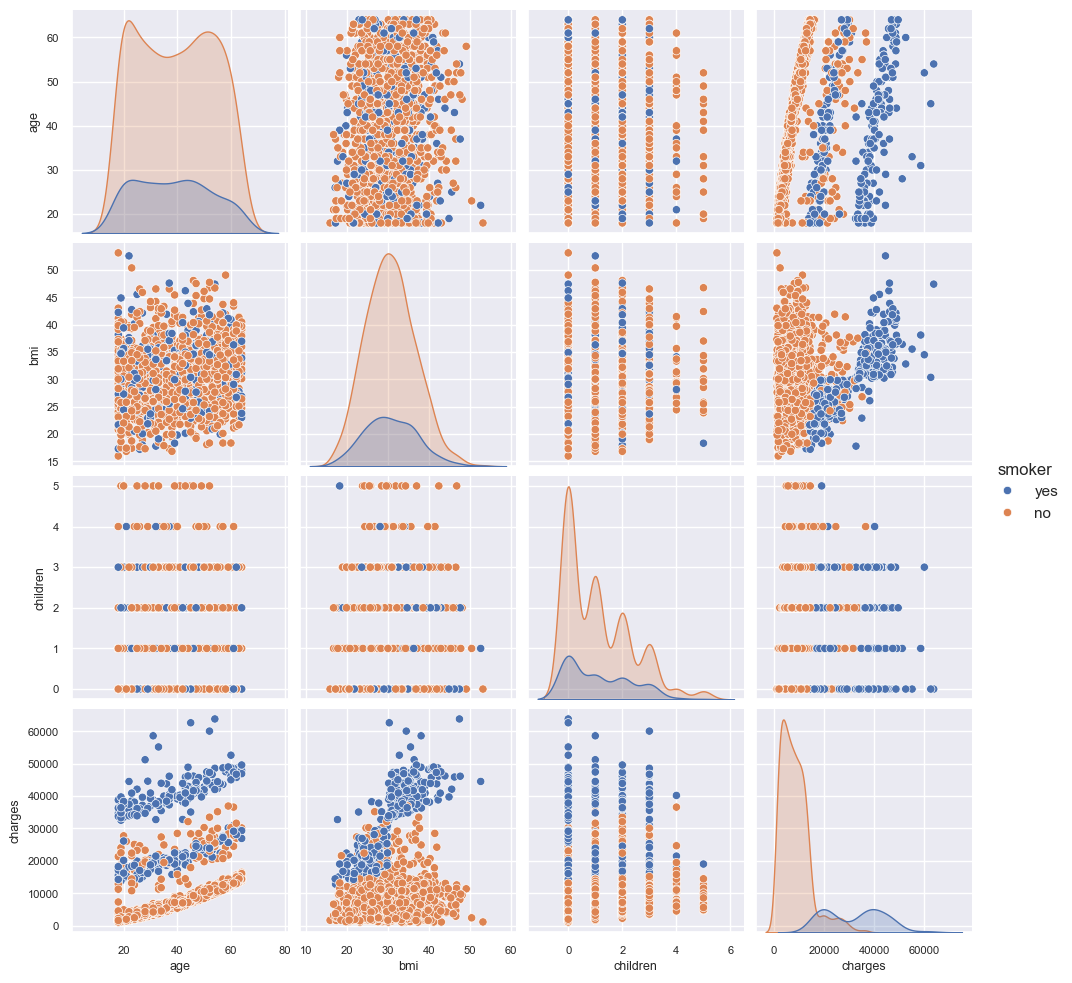

In [21]:
sns.pairplot(df,hue="smoker")
plt.show()

In [22]:
x=df.drop(columns=['charges'])
y=df['charges']
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [23]:
nums_cols_pipe=X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_pipe=X_train.select_dtypes(include=["string"]).columns.tolist()


In [24]:
nums_cols_pipe
cat_cols_pipe

[]

In [25]:
numeric_cols_pipe=Pipeline(
    steps=[
        ("scaler",StandardScaler())
    ]
)

categorical_cols_pipe=Pipeline(
    steps=[
        ("ohe",OneHotEncoder(drop="first",handle_unknown="ignore"))
    ]
)

preprocess=ColumnTransformer(
    transformers=[
        ("nums",numeric_cols_pipe,nums_cols_pipe),
        ("cat",categorical_cols_pipe,cat_cols_pipe),
        
        
    ]
)

In [26]:
baseline_pipe=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",LinearRegression())
    ]
)

In [27]:
baseline_pipe.fit(X_train,y_train)  

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [])])),
                ('model', LinearRegression())])

In [28]:
y_train_pred=baseline_pipe.predict(X_train)
y_test_pred=baseline_pipe.predict(X_test)

y_train_mse=root_mean_squared_error(y_train,y_train_pred)
y_train_mae=mean_absolute_error(y_train,y_train_pred)
y_train_r2=r2_score(y_train,y_train_pred)


print(" Root Mean squared Error :" ,y_train_mse)
print(" Mean Absolute Error :",y_train_mae )
print(" r2 Score :",y_train_r2 )




 Root Mean squared Error : 11041.004393703523
 Mean Absolute Error : 8750.063818645813
 r2 Score : 0.10963684231194992


In [29]:
y_test_mse=root_mean_squared_error(y_test,y_test_pred)
y_test_mae=mean_absolute_error(y_test,y_test_pred)
y_test_r2=r2_score(y_test,y_test_pred)


print(" Root Mean squared Error :" ,y_test_mse)
print(" Mean Absolute Error :",y_test_mae )
print(" r2 Score :",y_test_r2 )



 Root Mean squared Error : 12589.409964694136
 Mean Absolute Error : 9620.928319571061
 r2 Score : 0.13748020188497845


In [30]:
model_selection={
    'LinearRegression':LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(random_state=42,max_iter=10000),
    "DecisionTree":DecisionTreeRegressor(random_state=42),
    "RandomForest":RandomForestRegressor(random_state=42),
    "XGBoost":XGBRegressor()
}

In [31]:
k=5
cv=KFold(n_splits=5,shuffle=True,random_state=42)

In [32]:
scoring={
    "mae":"neg_mean_absolute_error",
    'rmse':"neg_root_mean_squared_error",
    "r2_score":"r2"
}

In [33]:
rows=[]
for name,model in model_selection.items():
    pipe=Pipeline(
        steps=[
            ("preprocess",preprocess),
            ('model',model)
        ]
    )
    
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append({
        'model':name,
        "cv_mae":-scores['test_mae'].mean(),
        "cv_rmse":-scores['test_rmse'].mean(),
        "cv_r2":-scores['test_r2_score'].mean()
        
        
    })
    
    
cv_results=pd.DataFrame(rows).sort_values("cv_mae")
print("--------CV mModel comparison___________")
    
    

--------CV mModel comparison___________


In [34]:
cv_results

,model,cv_mae,cv_rmse,cv_r2
1,Ridge,8770.065,11070.866,-0.098
2,Lasso,8770.184,11070.907,-0.098
0,LinearRegression,8770.189,11070.906,-0.098
4,RandomForest,8933.859,12181.494,0.094
5,XGBoost,9370.090,13203.359,0.289
3,DecisionTree,9590.874,15644.439,0.814


In [35]:
best_rows=cv_results.sort_values('cv_mae').iloc[0]
best_model_name=best_rows['model']
best_mae=best_rows['cv_mae']


print("Best model based on result")
print("model :",best_model_name)
print("cv mae:",best_mae)

Best model based on result
model : Ridge
cv mae: 8770.064647686868


In [36]:
hyper_pipe=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ("model",RandomForestRegressor(
            n_jobs=-1,
            random_state=42,
            verbose=True
            
            
        ))
    ]
)

In [37]:
param_grid={
    'model__n_estimators':[200,300,600,900],
    "model__max_depth":[None,8,15,25],
    
    "model__min_samples_split":[2,5,10],
    "model__min_samples_leaf":[1,2,4],
    
    'model__max_features':['sqrt','log2',0.6,0.8],
    "model__bootstrap":[True]
}

In [38]:
grid=GridSearchCV(
    estimator=hyper_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
    
)

In [39]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    0.7s finished


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('nums',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['age',
                                                                          'bmi',
                                                                          'children']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         [])])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42,
                                                              verbose=True))]),
             n_jobs=-1,
             param_grid={'model__bootstrap': [True],
                         'model__max_depth': [None, 8, 15, 25],
                         'model__max_features': ['sqrt', 'log2', 0.6, 0.8],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [200, 300, 600, 900]},
             scoring='neg_mean_absolute_error', verbose=1)

In [40]:
print("best cv mae:",-grid.best_score_)
print("best params:",grid.best_params_)


best cv mae: 8699.916280332789
best params: {'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 200}


Retrain our model

In [41]:
retrain=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=2,
            n_estimators=300,
            random_state=42,
            verbose=0
            
            
            
        ))
    ]
)

In [42]:
retrain.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  Pipeline(steps=[('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  [])])),
                ('model',
                 RandomForestRegressor(max_depth=8, max_features=0.8,
                                       min_samples_leaf=4, n_estimators=300,
                                       random_state=42))])

In [43]:
y_train_pred=retrain.predict(X_train)
y_test_pred=retrain.predict(X_test)

In [44]:
y_train_mse=root_mean_squared_error(y_train,y_train_pred)
y_train_mae=mean_absolute_error(y_train,y_train_pred)
y_train_r2=r2_score(y_train,y_train_pred)


print(" Root Mean squared Error :" ,y_train_mse)
print(" Mean Absolute Error :",y_train_mae )
print(" r2 Score :",y_train_r2 )



 Root Mean squared Error : 9223.35339468081
 Mean Absolute Error : 7145.777962570378
 r2 Score : 0.37866228820720493


In [45]:
y_test_mse=root_mean_squared_error(y_test,y_test_pred)
y_test_mae=mean_absolute_error(y_test,y_test_pred)
y_test_r2=r2_score(y_test,y_test_pred)


print(" Root Mean squared Error :" ,y_test_mse)
print(" Mean Absolute Error :",y_test_mae )
print(" r2 Score :",y_test_r2 )



 Root Mean squared Error : 13024.410703872158
 Mean Absolute Error : 9796.931789464725
 r2 Score : 0.07684529994504807


In [46]:
rf_best_log=TransformedTargetRegressor(
    regressor=Pipeline(
    steps=[
        ("preprocess",preprocess),
        ("model",RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=2,
            n_estimators=300,
            random_state=42,
            verbose=0 
        ))
    ]
),
    func=np.log1p,
    inverse_func=np.expm1
)

In [47]:
rf_best_log.fit(X_train,y_train)


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(transformers=[('nums',
                                                                                       Pipeline(steps=[('scaler',
                                                                                                        StandardScaler())]),
                                                                                       ['age',
                                                                                        'bmi',
                                                                                        'children']),
                                                                                      ('cat',
                                                                                       Pipeline(steps=[('ohe',
                                                                                                        OneHotEncoder(drop='first',
                                                                                                                      handle_unknown='ignore'))]),
                                                                                       [])])),
                                                     ('model',
                                                      RandomForestRegressor(max_depth=8,
                                                                            max_features=0.8,
                                                                            min_samples_leaf=4,
                                                                            n_estimators=300,
                                                                            random_state=42))]))

In [48]:
y_train_pred_log=rf_best_log.predict(X_train)
y_test_pred_log=rf_best_log.predict(X_test)

In [49]:
y_train_mse_log=root_mean_squared_error(y_train,y_train_pred_log)
y_train_mae_log=mean_absolute_error(y_train,y_train_pred_log)
y_train_r2_log=r2_score(y_train,y_train_pred_log)


print(" Root Mean squared Error :" ,y_train_mse_log)
print(" Mean Absolute Error :",y_train_mae_log )
print(" r2 Score :",y_train_r2_log )



 Root Mean squared Error : 10348.31425421222
 Mean Absolute Error : 6335.794380263272
 r2 Score : 0.21785147048052156


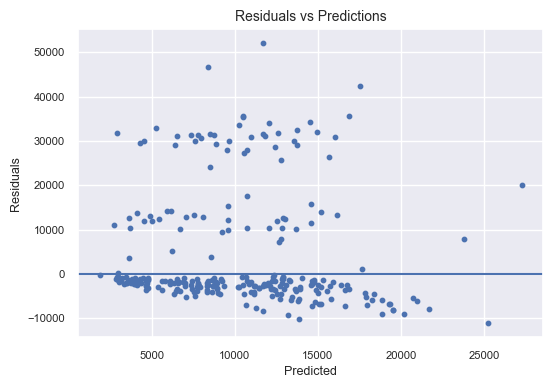

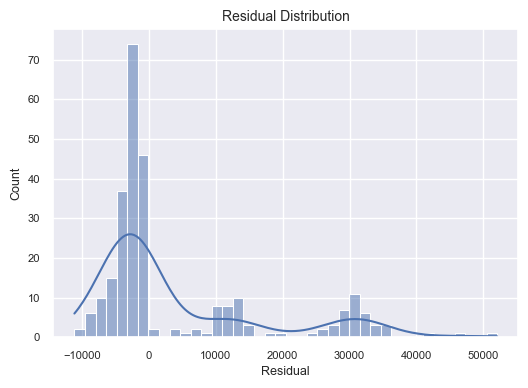

In [50]:
# residual plot
residuals = y_test - y_test_pred_log

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred_log, residuals, s=10)
plt.axhline(8)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt. show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt. show()


In [51]:
def insurance_predictor(
    age:float,
    sex:str,
    bmi:float,
    children:int,
    smoker:str,
    region:str,
    
):
    new_rows=pd.DataFrame([{
        "age":age,
        "sex":sex,
        "bmi":bmi,
        "children":children,
        "smoker":smoker,
        "region":region
    }])
    
    insurance=retrain.predict(new_rows)[0]
    return round(insurance,4)
    
    
    
    # return float(model.predict(new_rows)[0])

In [52]:
pred = insurance_predictor(

age=35,
sex="male",
bmi=29.5,
children=2,
smoker="no",
region="southeast"
)


In [53]:
print(pred)

8520.1347


In [54]:
import pickle
with open("retrain_model.pkl",'wb') as file:
    pickle.dump(retrain,file)
    
    
    


In [55]:
with open("log_model.pkl","wb") as file:
    pickle.dump(rf_best_log,file)
          

In [56]:
X_test

,age,sex,bmi,children,smoker,region
900,49,male,22.515,0,no,northeast
1064,29,female,25.600,4,no,southwest
1256,51,female,36.385,3,no,northwest
298,31,male,34.390,3,yes,northwest
237,31,male,38.390,2,no,southeast
...,...,...,...,...,...,...
534,64,male,40.480,0,no,southeast
542,63,female,36.300,0,no,southeast
760,22,female,34.580,2,no,northeast
1284,61,male,36.300,1,yes,southwest


In [57]:
y_test.loc[900]

np.float64(8688.85885)